# HiRAG-Ontology — Knowledge Graph Explorer

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ekaesha/hirag-ontology/blob/main/graph_explorer.ipynb)

Interactive visualisation and analysis of the knowledge graph.

**In Colab:** runs automatically with the demo graph (25 entities).  
**Locally:** run `py -m evaluation.run_eval` first to build the full graph.

In [2]:
# Setup — works both locally and in Colab
import os, sys, json
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !git clone https://github.com/ekaesha/hirag-ontology.git --quiet
    %cd hirag-ontology
    !pip install sentence-transformers rank-bm25 networkx -q

sys.path.insert(0, '.')

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import Counter, defaultdict

print('Setup complete!')

Setup complete!


In [3]:
# Load knowledge graph (or build demo if not found)
GRAPH_PATH = 'results/knowledge_graph_final.json'

if os.path.exists(GRAPH_PATH):
    with open(GRAPH_PATH, encoding='utf-8') as f:
        kg_data = json.load(f)
    print(f'Loaded full graph: {len(kg_data["entities"])} entities, {len(kg_data["relations"])} relations')
else:
    print('Full graph not found — building demo graph...')
    from evaluation.run_eval import create_demo_graph
    import os
    os.makedirs('results', exist_ok=True)
    kg = create_demo_graph()
    kg.save(GRAPH_PATH)
    with open(GRAPH_PATH, encoding='utf-8') as f:
        kg_data = json.load(f)
    print(f'Demo graph built: {len(kg_data["entities"])} entities, {len(kg_data["relations"])} relations')

Loaded full graph: 3793 entities, 4245 relations


In [4]:
# Build NetworkX graph
G = nx.DiGraph()
entity_map = {e['id']: e for e in kg_data['entities']}

for e in kg_data['entities']:
    G.add_node(e['id'], label=e['label'], entity_type=e['entity_type'])

for r in kg_data['relations']:
    G.add_edge(r['subject_id'], r['object_id'],
               predicate=r['predicate'], weight=r['confidence'])

degrees = dict(G.degree())
pagerank = nx.pagerank(G, alpha=0.85, max_iter=200)

print(f'Nodes: {G.number_of_nodes()}')
print(f'Edges: {G.number_of_edges()}')
print(f'Density: {nx.density(G):.6f}')
print(f'Weakly connected components: {nx.number_weakly_connected_components(G)}')

print('\nTop 10 by PageRank:')
for eid, score in sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:10]:
    e = entity_map[eid]
    print(f'  {score:.4f}  {e["label"]} ({e["entity_type"]})')

Nodes: 3793
Edges: 3776
Density: 0.000263
Weakly connected components: 1186

Top 10 by PageRank:
  0.0163  ОЛЛ (Condition)
  0.0080  ОМЛ (Condition)
  0.0078  Рак билиарного тракта (Condition)
  0.0073  Рак желчного пузыря (Condition)
  0.0072  Базальноклеточный рак кожи (Condition)
  0.0069  ОПЛ (Condition)
  0.0066  Острый лимфобластный лейкоз (ОЛЛ) (Condition)
  0.0061  РЖП (Condition)
  0.0057  АКР (Condition)
  0.0049  веко (AnatomicalStructure)


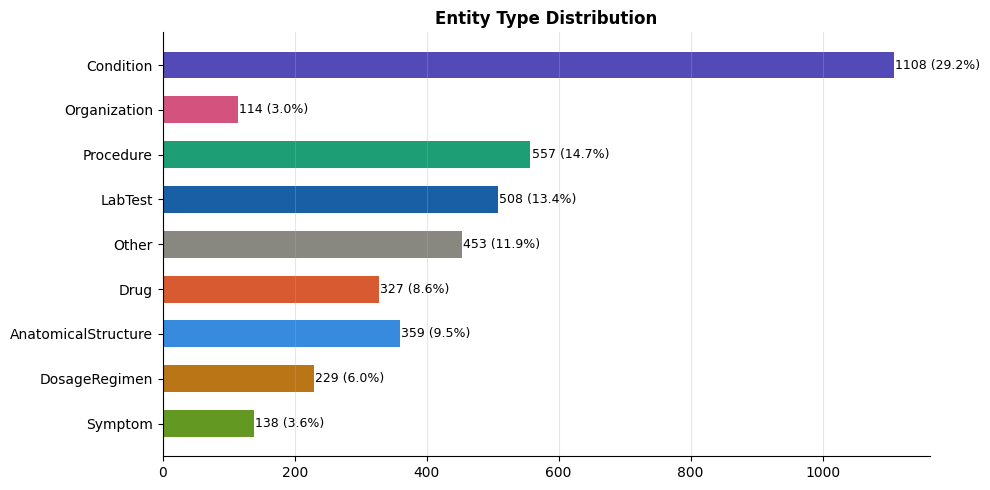

In [5]:
# Fig 1: Entity type distribution
TYPE_COLORS = {
    'Condition':'#534AB7', 'LabTest':'#185FA5', 'Other':'#888780',
    'Procedure':'#1D9E75', 'Drug':'#D85A30', 'AnatomicalStructure':'#378ADD',
    'DosageRegimen':'#BA7517', 'Organization':'#D4537E', 'Symptom':'#639922',
}
type_counts = Counter(e['entity_type'] for e in kg_data['entities'])

fig, ax = plt.subplots(figsize=(10, 5))
labels = list(type_counts.keys())
values = list(type_counts.values())
colors = [TYPE_COLORS.get(l, '#888') for l in labels]
bars = ax.barh(labels, values, color=colors, height=0.6, edgecolor='none')
for bar, val in zip(bars, values):
    pct = val / sum(values) * 100
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{val} ({pct:.1f}%)', va='center', fontsize=9)
ax.set_title('Entity Type Distribution', fontweight='bold')
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('results/nb_entity_types.png', dpi=150, bbox_inches='tight')
plt.show()

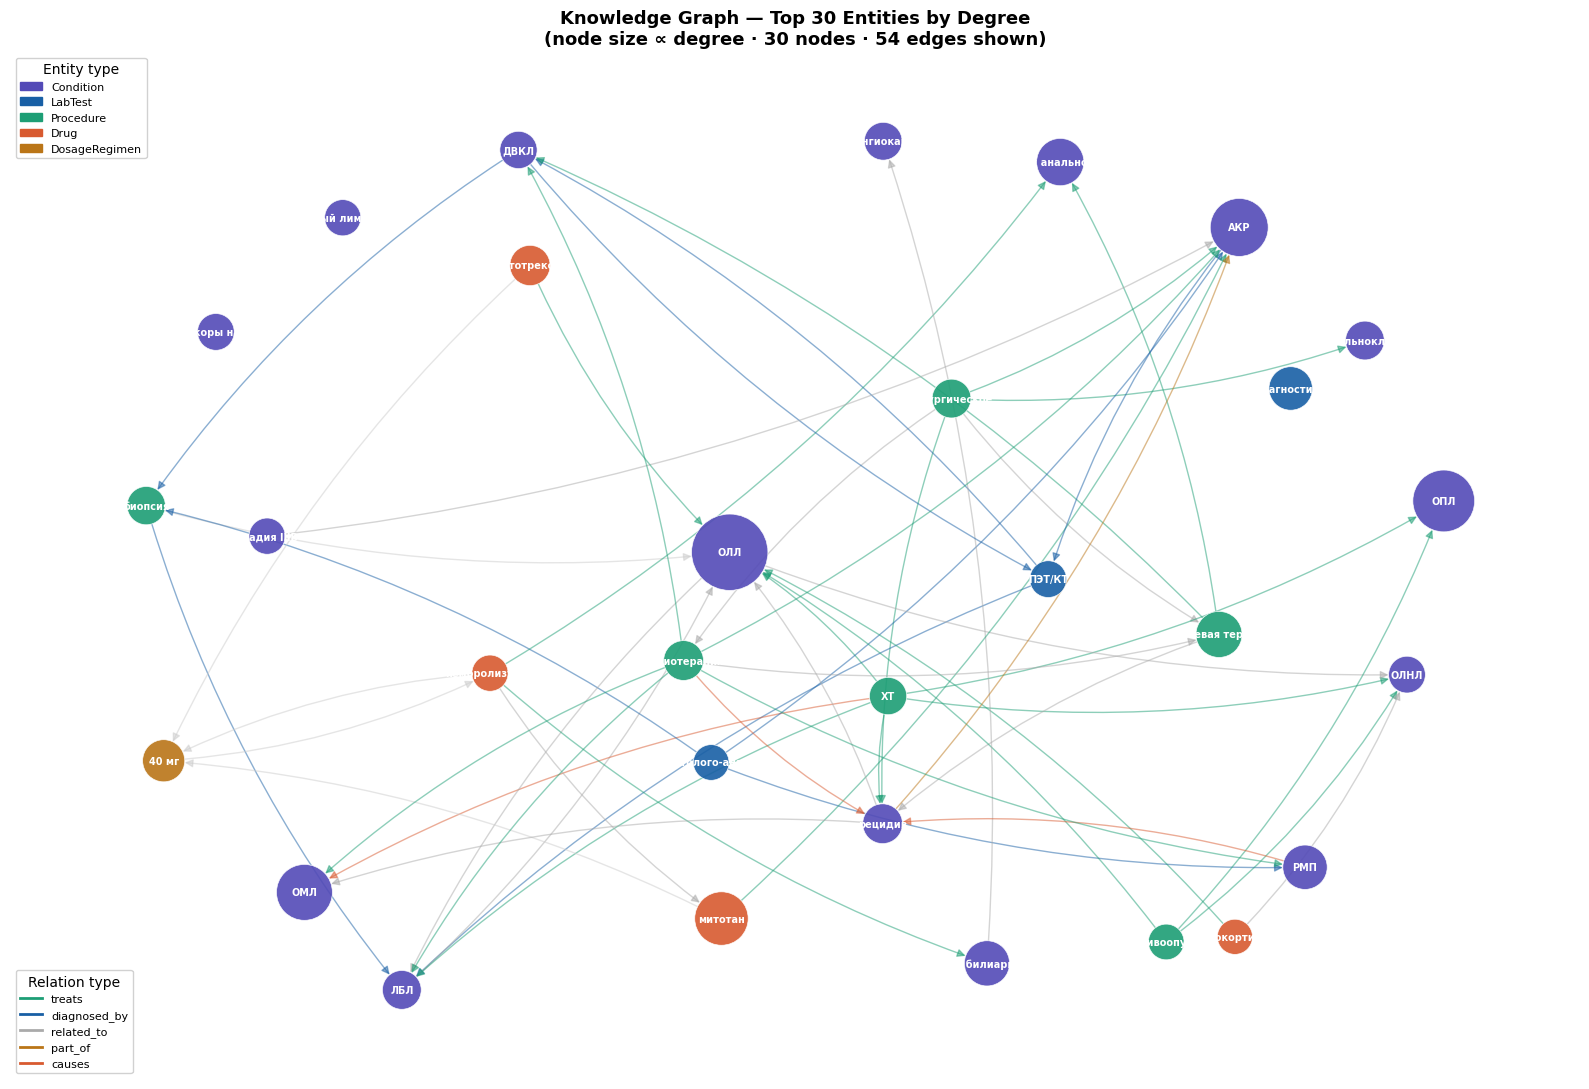

Saved to results/nb_graph_viz.png


In [6]:
# Fig 2: NetworkX graph visualisation
n_nodes = min(30, len(G.nodes()))
top_nodes = [n for n, _ in sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:n_nodes]]
subG = G.subgraph(top_nodes).copy()
pos = nx.spring_layout(subG, k=2.5, seed=42, iterations=100)

node_colors = [TYPE_COLORS.get(entity_map[n]['entity_type'], '#888') for n in subG.nodes()]
node_sizes  = [degrees[n] * 20 + 200 for n in subG.nodes()]
node_labels = {n: entity_map[n]['label'][:14] for n in subG.nodes()}

PRED_COLORS = {
    'treats':'#1D9E75', 'diagnosed_by':'#185FA5',
    'related_to':'#AAAAAA', 'part_of':'#BA7517', 'causes':'#D85A30',
}
edge_colors = [PRED_COLORS.get(
    subG[u][v]['predicate'], '#ccc') for u, v in subG.edges()]

fig, ax = plt.subplots(figsize=(16, 11))
ax.set_facecolor('#FAFAFA')

nx.draw_networkx_edges(subG, pos, ax=ax, edge_color=edge_colors,
    alpha=0.5, arrows=True, arrowsize=12,
    connectionstyle='arc3,rad=0.1', node_size=node_sizes)
nx.draw_networkx_nodes(subG, pos, ax=ax, node_color=node_colors,
    node_size=node_sizes, alpha=0.9, linewidths=0.5, edgecolors='white')
nx.draw_networkx_labels(subG, pos, node_labels, ax=ax,
    font_size=7, font_color='white', font_weight='bold')

node_legend = [mpatches.Patch(color=c, label=t)
    for t, c in TYPE_COLORS.items()
    if any(entity_map[n]['entity_type'] == t for n in subG.nodes())]
from matplotlib.lines import Line2D
edge_legend = [Line2D([0],[0], color=c, lw=2, label=p)
    for p, c in PRED_COLORS.items()]
leg1 = ax.legend(handles=node_legend, title='Entity type',
    loc='upper left', fontsize=8, framealpha=0.9)
ax.add_artist(leg1)
ax.legend(handles=edge_legend, title='Relation type',
    loc='lower left', fontsize=8, framealpha=0.9)

ax.set_title(
    f'Knowledge Graph — Top {n_nodes} Entities by Degree\n'
    f'(node size ∝ degree · {subG.number_of_nodes()} nodes · '
    f'{subG.number_of_edges()} edges shown)',
    fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('results/nb_graph_viz.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to results/nb_graph_viz.png')

In [7]:
# Subgraph query — inspect any entity
QUERY = 'ОЛЛ'  # Change to any entity label

target = next((e['id'] for e in kg_data['entities']
               if e['label'] == QUERY), None)

if target:
    print(f"Entity: {QUERY} (type: {entity_map[target]['entity_type']})")
    print(f"Degree: {degrees[target]}")
    print(f"PageRank: {pagerank[target]:.4f}")
    print(f"\nOutgoing relations:")
    for u, v, d in G.edges(target, data=True):
        print(f"  → [{d['predicate']}] → {entity_map[v]['label']}")
    print(f"\nIncoming relations:")
    for u, v, d in G.in_edges(target, data=True):
        print(f"  ← [{d['predicate']}] ← {entity_map[u]['label']}")
else:
    print(f"'{QUERY}' not found. Available entities:")
    for e in list(kg_data['entities'])[:10]:
        print(f"  {e['label']} ({e['entity_type']})")

Entity: ОЛЛ (type: Condition)
Degree: 141
PageRank: 0.0163

Outgoing relations:
  → [related_to] → ЛБЛ
  → [related_to] → кожа
  → [diagnosed_by] → бластных клеток
  → [related_to] → клеток-предшественников лимфопоэза
  → [diagnosed_by] → иммунофенотипирование
  → [related_to] → коморбидность
  → [related_to] → В-ЛБЛ
  → [part_of] → лейкозы
  → [part_of] → ОЛ
  → [diagnosed_by] → российской исследовательской группы по лечению лейкозов
  → [causes] → гипогаммаглобулинемия
  → [causes] → цитопения
  → [causes] → тромбоцитопения
  → [causes] → аномальные маточные кровотечения
  → [related_to] → инфекционных осложнений
  → [related_to] → Т-ЛБЛ
  → [related_to] → Ph-позитивный ОЛЛ
  → [related_to] → BCR-ABL1-подобных ОЛЛ
  → [related_to] → ETP-ОЛЛ
  → [diagnosed_by] → костном мозге
  → [diagnosed_by] → проточной цитометрии
  → [causes] → слабость
  → [causes] → лихорадка
  → [causes] → недомогание
  → [causes] → боли в костях
  → [causes] → боли в суставах
  → [causes] → кровоточивость со с